# Notebook 15 (V4_3) — First-window AHP calibration with pathwise common growth

This notebook re-centers the calibration on the preferred **time-invariant** search result, while restoring Notebook 12's exact pathwise common-growth construction. The economic target is the AHP pattern over the first 15 model periods: a negative U.S. NFA movement driven mainly by price revaluation of foreign-held U.S. equity claims, with cumulative valuation effects larger than cumulative current-account quantity flows.

The later path remains visible and is exported, but it receives exactly zero weight in candidate selection. This implements the interpretation that the post-15 rebound occurs far beyond the empirical window and is not a first-order calibration failure.

The detailed, executable search is kept in `15_v9_ahp_pattern_calibration_search.jl` so the same calibration can be run either from this notebook or non-interactively.


## Calibration design

The time-invariant winner supplies the period-15 magnitude targets: rebased NFA change `-0.15294`, cumulative net VA `-0.10661`, cumulative CA `-0.04633`, asset VA `-0.00568`, and liability VA `-0.10093`, all divided by period-15 U.S. output. Exact replication is not required.

Candidate ranking uses only periods `1:15`. NFA, net VA, and liability VA receive the largest weights. CA receives a small magnitude weight and only a mechanism penalty if it becomes larger than VA. There is no penalty for post-period-15 rebound, full-horizon NFA direction, the sign of asset VA, CA backtracking, or RoW-price smoothness.

The search is sequential. First, representative hard-valid changes to the RoW growth block alone must fail the AHP mechanism. Only then does the notebook activate a joint search centered on the old financial block. Every selected path must pass model, interiority, accounting, return, and positivity checks; every reported-plus-buffer switch-state BGP must converge; and every state-specific `nu_b_eff` must impose common growth exactly while remaining below `nu_u`.


  Activating 

Julia version:              1

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


.12.1
Project directory:          /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes
Time-invariant benchmark:   /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search
Output directory:           /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_first_window_common_growth_search
Execution mode:             FULL
AHP evidence endpoint:      t=15
Search/reporting horizons:  15 / 30

Time-invariant target at t=15
  rebased NFA change/current Y: -0.152935
  cumulative net VA/current Y: -0.106609
  cumulative CA/current Y:     -0.046326
  asset/liability VA:          -0.005681 / -0.100928


Stage A: representative RoW-growth-only confirmation
RoW-only:                row_only_low_xiw                 NFA=+0.0559 VA=-0.2460 [A=-0.2450 L=-0.0010] C

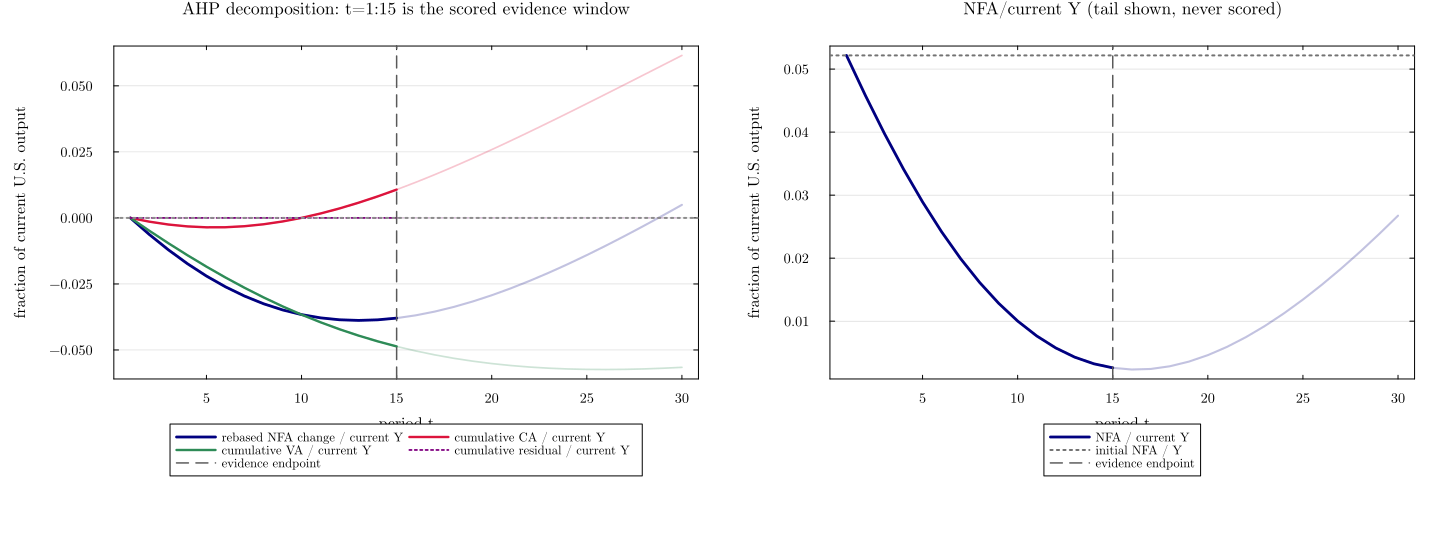

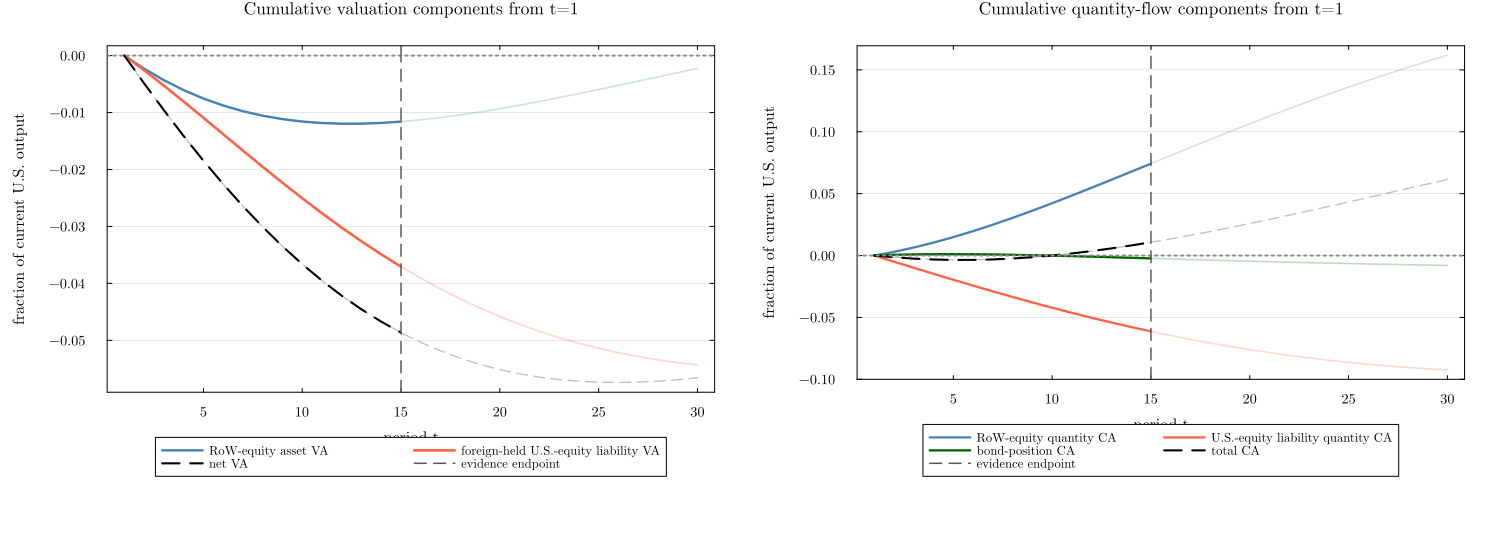

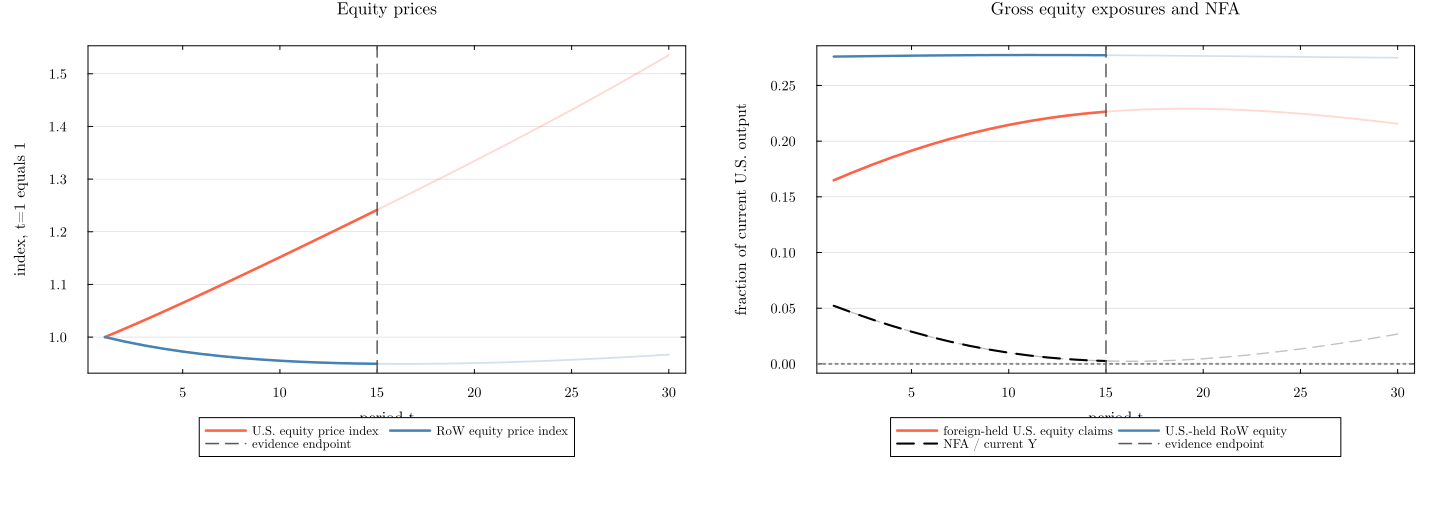

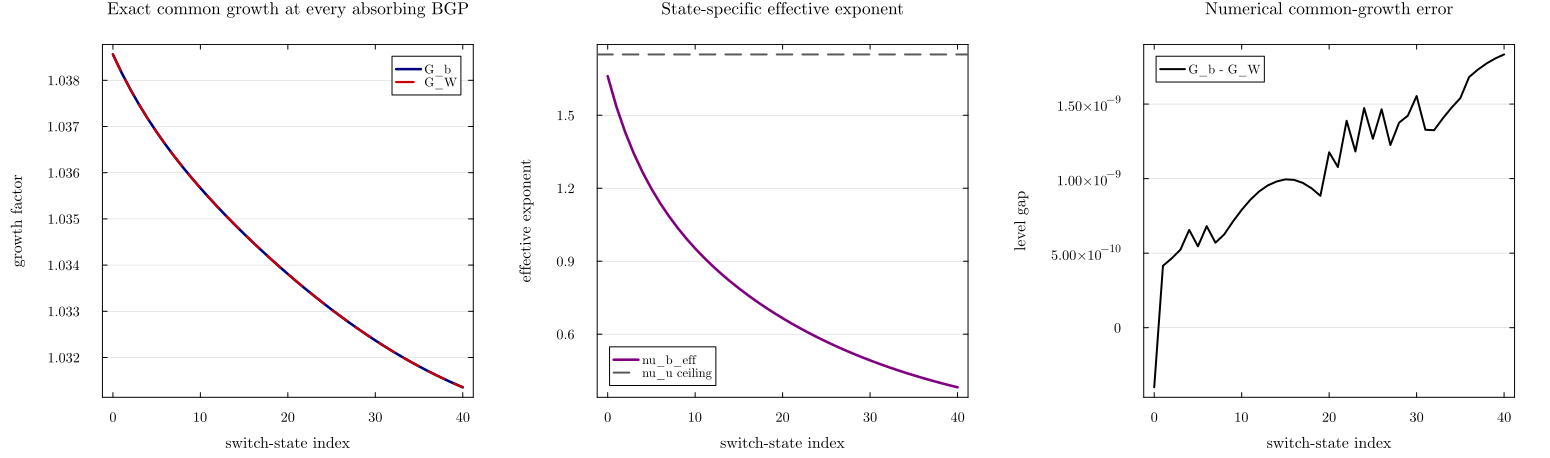


NOTEBOOK 15 — FIRST-WINDOW AHP CALIBRATION WITH PATHWISE COMMON GROWTH
Selected candidate:               pathwise_hi_exp_pi075
Classification:                   first_window_common_growth_strong_partial_match
Target-window rebased NFA:        -0.037937 (time-invariant target -0.152935)
Target-window net VA:             -0.048656 (target -0.106609)
  asset / liability VA:           -0.011597 / -0.037059
Target-window cumulative CA:      +0.010719 (target -0.046326)
|VA| / |CA|:                      4.539
Foreign U.S.-equity exposure:     0.205
Reference calibrated nu_b:        1.660653
State-specific nu_b_eff range:    [0.381620, 1.660653]
Maximum common-growth log gap:    1.777e-09
Maximum extended-BGP residual:    9.971e-10
Unscored post-target rebound:      +0.042887
Tail enters calibration score:     false
Artifacts written to:              /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern

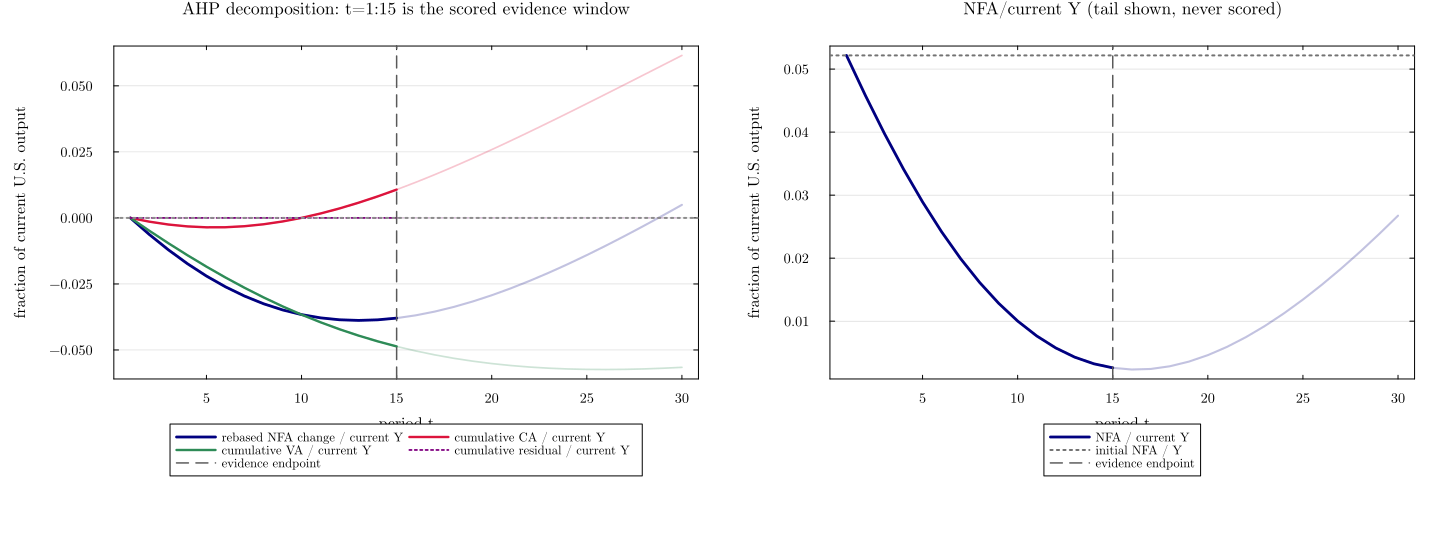

In [1]:
function nb15_find_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not locate Project.toml from $(start_dir)")
        dir = parent
    end
end

nb15_project_dir = nb15_find_project_dir()
include(joinpath(nb15_project_dir, "Two_country_production",
                 "15_v9_ahp_pattern_calibration_search.jl"))


## Parameter changes relative to the time-invariant winner

| Parameter | Time-invariant winner | Selected pathwise-common value | Main role |
|---|---:|---:|---|
| `common_world_growth` | `false` | `true` | Activates exact common growth at every absorbing switch-state BGP. |
| `a_W` | `0.10` | `0.06` | Reduces RoW growth pressure enough to make the common-growth selector feasible without the low-`xi_W` collapse in `q_W`. |
| `xi_W` | `1.00` | `1.00` | Kept high; low values make the decomposition asset-led through falling RoW equity prices. |
| `pi_persist` | `0.80` | `0.75` | Slightly advances the transition and improves early liability revaluation. |
| `vartheta_US` | `0.80` | `0.85` | Strengthens the transmission of U.S. growth news into `q_US`. |
| `A_X_US_u` | `10.0` | `15.0` | Main magnitude lever: raises U.S. equity-price appreciation in the evidence window. |
| `A_L_US_u` | `1.0` | `1.5` | Moves with `A_X_US_u`, preserving the internal U.S. technology composition. |
| `nu_u` | `1.40` | `1.75` | Raises the ceiling above all state-specific effective bubble exponents. |
| `xi_u` | `1.90` | `2.25` | Rises one-for-one with `nu_u`, preserving the original effective gap `xi_u - nu_u = 0.50`. |
| `beta`, `kappa` | `0.45`, `1.00` | unchanged | Retains the preferred time-invariant savings/portfolio block. |
| `omega_bar`, `omega_bar_star` | `0.50`, `0.25` | unchanged | Preserves large foreign-held U.S. equity claims; tested financial perturbations fit worse. |
| `chi`, `eta` | `0.0002`, `0.010` | unchanged | Retains the preferred portfolio-cost block. |
| reference `nu_b` | input seed `0.10` | calibrated near `1.66` | Absorbs the remaining reference-BGP growth mismatch. It is not treated as one exponent valid at all states. |
| pathwise `nu_b_eff` | not used | state specific | Restores exact common growth at each switch-state BGP while all structural primitives above stay time invariant. |

The changes are jointly calibrated, so the role descriptions are mechanism interpretations rather than separately identified causal effects. `best_parameters.csv` records the exact selected values and effects.


In [2]:
println("\nFirst-window attainment relative to the preferred time-invariant target:")
@printf("  NFA magnitude:          %6.1f%%\n",
        100 * abs(best_metrics.target_rebased_nfa / AHP_TARGET.rebased_nfa))
@printf("  net-VA magnitude:       %6.1f%%\n",
        100 * abs(best_metrics.target_net_va / AHP_TARGET.net_va))
@printf("  liability-VA magnitude: %6.1f%%\n",
        100 * abs(best_metrics.target_liability_va / AHP_TARGET.liability_va))
@printf("  |VA| / |CA|:            %6.2f\n",
        abs(best_metrics.target_net_va) / max(abs(best_metrics.target_ca), 1e-12))
println("  tail scored:             false")



First-window attainment relative to the preferred time-invariant target:
  NFA magnitude:            24.8%
  net-VA magnitude:         45.6%
  liability-VA magnitude:   36.7%
  |VA| / |CA|:              4.54
  tail scored:             false


## Interpretation

“Rebased NFA change” means `(NFA_t - NFA_1) / Y_t`: the initial nominal NFA level is subtracted before division by current output. It therefore starts at zero and obeys the plotted AHP accounting decomposition into cumulative CA, cumulative VA, and the numerical residual, all normalized by the same current `Y_t`. It is not the same object as `NFA_t/Y_t - NFA_1/Y_1`, which also contains a denominator-growth effect.

The selected common-growth calibration is intentionally a partial magnitude match. Its first-window NFA fall is substantially larger than in the previous common-growth notebook, net VA dominates CA, and foreign-held U.S.-equity liability revaluation is the main valuation component. The later rebound is retained as a transparent diagnostic rather than hidden or optimized away.
